# Exercise 4: Transformers on Images + GLU-MLP Ablations (ViT × GLU Variants)

## In this exercise you will combine two influential ideas:

Vision Transformers (ViT) from “An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale” (Dosovitskiy et al., 2020) https://arxiv.org/pdf/2010.11929:
ViT shows that you can treat an image like a sequence of tokens by splitting it into non-overlapping patches (e.g. 16×16 in the paper), embedding each patch into a vector, adding positional information, and then applying standard Transformer blocks for classification.

Gated MLPs (GLU variants) from “GLU Variants Improve Transformer” (Shazeer, 2020) https://arxiv.org/pdf/2002.05202:
Shazeer proposes replacing the standard Transformer feed-forward layer (FFN/MLP) with gated linear unit (GLU) variants such as GEGLU and SwiGLU, which often improves training dynamics and final performance under comparable compute/parameter budgets.

## What you will do

You will implement a tiny ViT-style classifier for MNIST, then run a controlled ablation where you replace the MLP inside each Transformer block:

Baseline FFN (GELU):
Linear(d_model → d_ff) → GELU → Linear(d_ff → d_model)

GLU-family MLPs (choose at least two and justify):

GEGLU, SwiGLU, other activation functions

Your goal is to evaluate whether these GLU variants change:

- convergence speed (loss vs steps),

- final test accuracy,

- and/or stability across runs.

## Key ViT concepts you will implement

- To convert MNIST images into Transformer tokens, you will:
  Patchify each 28×28 image into non-overlapping P×P patches.
  If P=4, then you get a 7×7 patch grid → 49 tokens per image.

- Embed patches with a linear layer: patch vectors → d_model.

- Add positional embeddings so the model knows where each patch came from.

- Apply n_layers Transformer encoder blocks.

- Pool token features (e.g., mean pooling) and project to 10 classes.

## Key GLU concept you will implement

GLU-style MLPs replace a standard FFN with a gating mechanism:
compute two projections a and b, apply a nonlinearity to a (variant-dependent), multiply elementwise: act(a) * b, project back to d_model.
To keep the comparison fair, use the 2/3 width rule from Shazeer.

What we provide vs what you implement

### We provide:

- MNIST loading + dataloaders

- a minimal training loop structure (AdamW)

- a suggested small model configuration that runs on CPU

### You implement:

- patch tokenization (patchify)

- patch embedding + positional embedding strategy

- a pre-LN Transformer encoder block using nn.MultiheadAttention

- at least two GLU MLP variants + one FFN baseline

- metric logging sufficient to support your conclusion

## Deliverables

Run at least 3 variants (baseline + the activation functions you choose for GLU) and report:

- final and best test accuracy

- number of trainable parameters

- a plot or printed summary of loss/accuracy over epochs

- a short discussion of your results

In [1]:
from __future__ import annotations

import math
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [2]:
def patchify(x: torch.Tensor, patch_size: int) -> torch.Tensor:
    """Convert images to patch tokens."""
    B, C, H, W = x.shape
    assert H % patch_size == 0 and W % patch_size == 0, "Image dimensions must be divisible by the patch size."
    num_patches_h = H // patch_size
    num_patches_w = W // patch_size
    num_patches = num_patches_h * num_patches_w
    patch_dim = C * patch_size * patch_size
    # [B, C, grid_H, P_H, grid_W, P_W]
    patches = x.reshape(B, C, num_patches_h, patch_size, num_patches_w, patch_size)
    # [B, grid_H, grid_W, C, P_H, P_W]
    patches = patches.permute(0, 2, 4, 1, 3, 5)
    # [B, num_patches, patch_dim]
    patches = patches.reshape(B, num_patches, patch_dim)
    return patches

x = torch.randn(2, 1, 16, 16)
patch_size = 4
patches = patchify(x, patch_size)
print(patches.shape)  # Should print: torch.Size([2, 16, 16]) — 16 patches of dim C*P*P = 1*4*4

torch.Size([2, 16, 16])


In [3]:
class PatchEmbed(nn.Module):
    def __init__(self, patch_dim: int, d_model: int):
        super().__init__()
        self.proj = nn.Linear(patch_dim, d_model)

    def forward(self, x_patches: torch.Tensor) -> torch.Tensor:
        return self.proj(x_patches)


class PositionalEmbedding(nn.Module):
    def __init__(self, num_tokens: int, d_model: int):
        super().__init__()
        # Scale INSIDE nn.Parameter: `nn.Parameter(...) * 0.02` would create a
        # non-leaf tensor whose graph is built once in __init__ and reused every
        # forward -> "backward through the graph a second time" on step 2.
        self.pos_embedding = nn.Parameter(torch.randn(1, num_tokens, d_model) * 0.02)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pos_embedding

### Which GLU variants we compare, and why

We compare the **standard GELU FFN** (baseline) against three GLU-family MLPs, chosen so each comparison isolates a single design choice:

- **Bilinear** is the control: the gate `(xW1) ⊙ (xV)` with *no* nonlinearity at all. Baseline vs. Bilinear asks whether multiplicative interactions alone help.
- **GEGLU** keeps the *same* nonlinearity as the baseline (GELU) but adds the gate: `GELU(xW1) ⊙ xV`. Baseline vs. GEGLU isolates the **gating mechanism** with the activation held fixed.
- **SwiGLU** swaps GELU for Swish/SiLU inside the gate: `SiLU(xW1) ⊙ xV`. GEGLU vs. SwiGLU isolates the **choice of gate activation**.

GEGLU and SwiGLU were the strongest variants in Shazeer (2020) and are the ones adopted in practice (GEGLU: T5 v1.1, Gemma; SwiGLU: PaLM, LLaMA), so they are the most relevant to test.

**Fair parameter budget (2/3 width rule).** A GLU MLP has three weight matrices (`W1`, `V`, `W2`) instead of two, so with the same hidden width it would get ~50% more MLP parameters than the baseline. Following Shazeer, the gated hidden width is shrunk to `d_ff_gated = ⌊2/3 · d_ff⌋`, keeping all models at (almost) identical parameter counts — verified in Deliverable 2 below.

In [4]:
class FeedForward(nn.Module):
    """
    Standard Transformer FFN:
      x -> Linear(d_model->d_ff) -> GELU -> Dropout -> Linear(d_ff->d_model) -> Dropout
    """
    def __init__(self, d_model: int, d_ff: int, dropout: float):
        super().__init__()
        self.forward_net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.forward_net(x)


class GLUFeedForward(nn.Module):
    """GLU-family FFN: act(x @ W1) * (x @ V) -> W2, per Shazeer (2020)."""
    def __init__(self, d_model: int, d_ff_gated: int, dropout: float, variant: str):
        super().__init__()
        self.W1 = nn.Linear(d_model, d_ff_gated)
        self.V = nn.Linear(d_model, d_ff_gated)
        self.W2 = nn.Linear(d_ff_gated, d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.variant = variant

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x_proj = self.W1(x)
        x_gate = self.V(x)
        if self.variant == "Bilinear":
            pass
        elif self.variant == "GLU":
            x_gate = torch.sigmoid(x_gate)
        elif self.variant == "GEGLU":
            x_gate = F.gelu(x_gate)
        elif self.variant == "ReGLU":
            x_gate = F.relu(x_gate)
        elif self.variant == "SwiGLU":
            x_gate = F.silu(x_gate)
        else:
            raise ValueError(f"Unknown variant: {self.variant}")
        x = x_proj * x_gate
        x = self.dropout1(x)
        x = self.W2(x)
        x = self.dropout2(x)
        return x

In [ ]:
class TransformerEncoderBlock(nn.Module):
    """
    Pre-LN encoder block:
      x = x + Dropout(SelfAttn(LN(x)))
      x = x + Dropout(MLP(LN(x)))
    """
    def __init__(self, d_model: int, n_heads: int, mlp: nn.Module, dropout: float):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.self_attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=n_heads, dropout=dropout, batch_first=True)
        self.mlp = mlp
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.dropout(self.self_attn(self.ln1(x), self.ln1(x), self.ln1(x))[0])
        x = x + self.dropout(self.mlp(self.ln2(x)))
        return x

In [6]:
class TinyViT(nn.Module):
    """
    Tiny ViT-style classifier for MNIST.
    - patchify -> patch embed -> pos embed -> blocks -> mean pool -> head
    """
    def __init__(
        self,
        patch_size: int,
        d_model: int,
        n_heads: int,
        n_layers: int,
        d_ff: int,
        dropout: float,
        mlp_kind: str,
    ):
        super().__init__()
        assert 28 % patch_size == 0
        grid = 28 // patch_size
        self.num_tokens = grid * grid
        self.patch_size = patch_size
        patch_dim = patch_size * patch_size

        self.patch_embed = PatchEmbed(patch_dim=patch_dim, d_model=d_model)
        self.pos_embed = PositionalEmbedding(num_tokens=self.num_tokens, d_model=d_model)

        def make_mlp():
            if mlp_kind in ["Bilinear", "GLU", "GEGLU", "ReGLU", "SwiGLU"]:
                # 2/3 width rule (Shazeer 2020): a GLU MLP has 3 weight matrices
                # instead of 2, so shrink the hidden width to keep the parameter
                # budget comparable to the baseline FFN.
                return GLUFeedForward(d_model=d_model, d_ff_gated=int(d_ff * 2 / 3), dropout=dropout, variant=mlp_kind)
            else:
                return FeedForward(d_model=d_model, d_ff=d_ff, dropout=dropout)

        # Each block gets its OWN MLP instance via make_mlp() — building a single
        # MLP outside the loop would silently share weights across all layers.
        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                d_model=d_model,
                n_heads=n_heads,
                mlp=make_mlp(),
                dropout=dropout,
            )
            for _ in range(n_layers)
        ])

        self.head = nn.Linear(d_model, 10)  # MNIST has 10 classes

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.patch_embed(patchify(x, self.patch_size))
        x = self.pos_embed(x)
        for block in self.blocks:
            x = block(x)
        x = x.mean(dim=1)  # mean pool over tokens
        logits = self.head(x)
        return logits

In [7]:
@dataclass(frozen=True)
class TrainConfig:
    seed: int = 0
    batch_size: int = 128
    epochs: int = 3
    lr: float = 3e-4
    weight_decay: float = 0.01
    device: str = "cpu"  # set "cuda" if available

In [8]:
def train_one_run(
    mlp_kind: str,
    model: nn.Module,
    train_loader: DataLoader,
    test_loader: DataLoader,
    cfg: TrainConfig,
) -> dict:
    model.to(cfg.device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    train_losses: list[float] = []
    test_accs: list[float] = []

    for epoch in range(cfg.epochs):

        # Train loop
        model.train()
        for i, (xb, yb) in enumerate(train_loader):
            xb = xb.to(cfg.device)
            yb = yb.to(cfg.device)

            logits = model(xb)
            loss = F.cross_entropy(logits, yb)

            opt.zero_grad()
            loss.backward()
            opt.step()

            train_losses.append(loss.item())

        # Evaluation loop NOTE: Should be no need to change this
        model.eval()
        correct = 0.0
        total = 0.0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(cfg.device)
                yb = yb.to(cfg.device)
                logits = model(xb)
                correct += (logits.argmax(dim=-1) == yb).float().sum().item()
                total += yb.numel()

        test_accs.append(correct / total)
        print(f"[{mlp_kind}] epoch {epoch+1}/{cfg.epochs} | test acc: {test_accs[-1]:.4f}")

    # Per-step train loss supports the convergence-speed claim; per-epoch test
    # accuracy supports the final/best-accuracy claim.
    return {
        "train_losses": train_losses,
        "test_accs": test_accs,
    }

In [9]:
cfg = TrainConfig(seed=0, batch_size=128, epochs=5, lr=3e-4, weight_decay=0.01, device="cpu")

tfm = transforms.Compose([transforms.ToTensor()])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
test_ds = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)

# Tiny model that trains on CPU in a few minutes per run
patch_size = 4
d_model = 64
n_heads = 4
n_layers = 2
d_ff = 256
dropout = 0.1

# Baseline + the three GLU variants justified above.
# Also implemented: "GLU" (sigmoid gate), "ReGLU" (relu gate)
runs = ["standard", "Bilinear", "GEGLU", "SwiGLU"]
results: dict[str, dict] = {}

for kind in runs:
    # Reseed per run so every variant sees the same init draws and the same
    # shuffled data order — differences between runs come from the MLP alone.
    torch.manual_seed(cfg.seed)
    model = TinyViT(
        patch_size=patch_size,
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        d_ff=d_ff,
        dropout=dropout,
        mlp_kind=kind,
    )
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nRun: {kind} | trainable params: {n_params:,}")
    out = train_one_run(kind, model, train_loader, test_loader, cfg)
    out["n_params"] = n_params
    results[kind] = out


Run: standard | trainable params: 104,842


[standard] epoch 1/5 | test acc: 0.8178


[standard] epoch 2/5 | test acc: 0.9006


[standard] epoch 3/5 | test acc: 0.9100


[standard] epoch 4/5 | test acc: 0.9303


...

[SwiGLU] epoch 1/5 | test acc: 0.8410


[SwiGLU] epoch 2/5 | test acc: 0.9079


[SwiGLU] epoch 3/5 | test acc: 0.9357


[SwiGLU] epoch 4/5 | test acc: 0.9460


[SwiGLU] epoch 5/5 | test acc: 0.9531


## Deliverables

The exercise asks for four things, each covered by one section below:

1. **Final and best test accuracy** per variant
2. **Number of trainable parameters** per variant (checking the 2/3 width rule keeps budgets fair)
3. **Loss / accuracy over training** (plot)
4. **Discussion** of the results

### Deliverable 1 — Final and best test accuracy

For each variant: test accuracy after the last epoch, the best test accuracy over all epochs, and the epoch where it occurred. This table (together with Deliverable 2) is also the plain-text companion to the plot below.

In [10]:
print(f"{'variant':<10} | {'final acc':>9} | {'best acc':>8} | {'best epoch':>10}")
print("-" * 48)
for kind, out in results.items():
    accs = out["test_accs"]
    best_epoch = max(range(len(accs)), key=lambda e: accs[e]) + 1
    print(f"{kind:<10} | {accs[-1]:>9.4f} | {max(accs):>8.4f} | {best_epoch:>10}")

variant    | final acc | best acc | best epoch
------------------------------------------------
standard   |    0.9380 |   0.9380 |          5
Bilinear   |    0.9463 |   0.9491 |          4
GEGLU      |    0.9519 |   0.9519 |          5
SwiGLU     |    0.9531 |   0.9531 |          5


### Deliverable 2 — Number of trainable parameters

Thanks to the 2/3 width rule (`d_ff_gated = ⌊2·256/3⌋ = 170` vs. `d_ff = 256`), the three weight matrices of the GLU variants cost almost exactly the same as the two wider matrices of the baseline — so any accuracy difference is attributable to the architecture, not to extra capacity.

In [11]:
base_params = results["standard"]["n_params"]
print(f"{'variant':<10} | {'trainable params':>16} | {'vs baseline':>11}")
print("-" * 45)
for kind, out in results.items():
    delta = 100.0 * (out["n_params"] - base_params) / base_params
    print(f"{kind:<10} | {out['n_params']:>16,} | {delta:>+10.2f}%")

variant    | trainable params | vs baseline
---------------------------------------------
standard   |          104,842 |      +0.00%
Bilinear   |          104,754 |      -0.08%
GEGLU      |          104,754 |      -0.08%
SwiGLU     |          104,754 |      -0.08%


### Deliverable 3 — Loss / accuracy over training

Two panels, one measure each: **left** — per-step training loss (raw curves faint, 50-step moving average on top) to compare *convergence speed*; **right** — test accuracy after every epoch to compare *final performance*. Each variant keeps the same color in both panels.

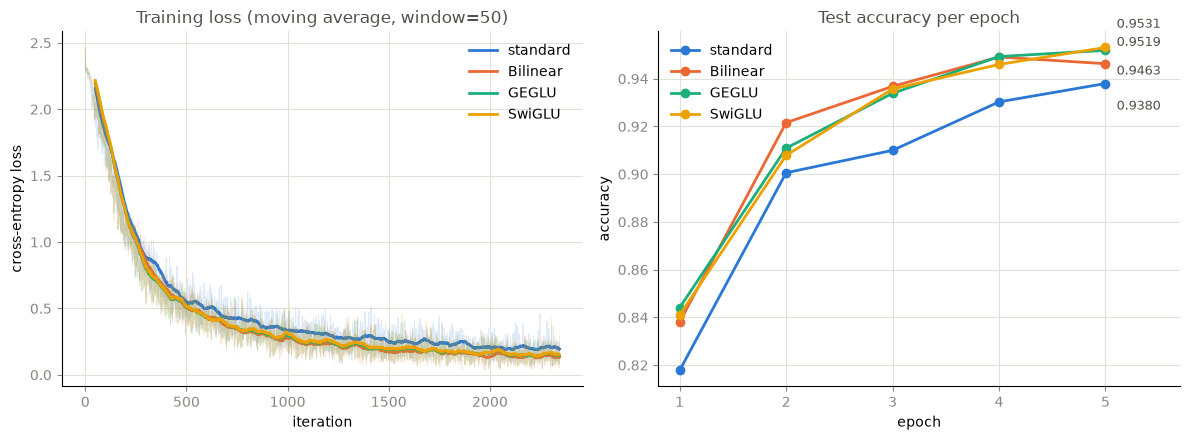

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Fixed color per variant (colorblind-safe categorical palette, fixed order)
COLORS = {"standard": "#2a78d6", "Bilinear": "#eb6834", "GEGLU": "#1baf7a", "SwiGLU": "#eda100"}
INK, MUTED, GRID = "#52514e", "#898781", "#e1e0d9"

def moving_average(values, window: int = 50):
    return np.convolve(values, np.ones(window) / window, mode="valid")

fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: per-step training loss (raw faint, smoothed on top) -> convergence speed
window = 50
for kind, out in results.items():
    color = COLORS.get(kind, MUTED)
    losses = np.asarray(out["train_losses"])
    ax_loss.plot(losses, color=color, linewidth=0.7, alpha=0.15)
    ax_loss.plot(np.arange(window - 1, len(losses)), moving_average(losses, window),
                 color=color, linewidth=2, label=kind)
ax_loss.set_title(f"Training loss (moving average, window={window})", color=INK)
ax_loss.set_xlabel("iteration")
ax_loss.set_ylabel("cross-entropy loss")

# Right: test accuracy per epoch -> final performance
for kind, out in results.items():
    epochs_x = np.arange(1, len(out["test_accs"]) + 1)
    ax_acc.plot(epochs_x, out["test_accs"], color=COLORS.get(kind, MUTED),
                linewidth=2, marker="o", markersize=6, label=kind)
# Stagger final-value labels by rank so they never overlap
order = sorted(results, key=lambda k: results[k]["test_accs"][-1], reverse=True)
for rank, kind in enumerate(order):
    final = results[kind]["test_accs"][-1]
    ax_acc.annotate(f"{final:.4f}", (epochs_x[-1], final),
                    xytext=(8, (len(order) - 1 - 2 * rank) * 5.5), textcoords="offset points",
                    fontsize=9, color=INK, va="center")
ax_acc.set_xlim(right=epochs_x[-1] + 0.7)
ax_acc.set_xticks(epochs_x)
ax_acc.set_title("Test accuracy per epoch", color=INK)
ax_acc.set_xlabel("epoch")
ax_acc.set_ylabel("accuracy")

for ax in (ax_loss, ax_acc):
    ax.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.tick_params(colors=MUTED)
    ax.legend(frameon=False)

fig.tight_layout()
plt.show()

### Deliverable 4 — Discussion

**Setup.** All four models are identical except the MLP inside each transformer block (2 layers, `d_model=64`, 4 heads, ~105k parameters, 5 epochs, AdamW, CPU). Every run reuses the same seed, so all variants see the same initialization draws and the same shuffled data order — the MLP is the only variable. One run per variant.

**Parameter parity held.** With the 2/3 width rule, the GLU variants have 104,754 trainable parameters vs. 104,842 for the baseline (−0.08%), so the differences below are architectural, not extra capacity.

**Ranking (final test accuracy):** SwiGLU **0.9531** > GEGLU **0.9519** > Bilinear **0.9463** (best 0.9491 at epoch 4) > standard FFN **0.9380**.

- **Gating helps.** Every gated variant beat the baseline by 0.8–1.5 accuracy points at the same parameter budget. Notably, even **Bilinear** — a gate with *no* nonlinearity — gains ~0.8 points, so a large share of the benefit comes from the multiplicative interaction itself, not from the activation function.
- **A nonlinear gate helps further.** GEGLU and SwiGLU add another ~0.6 points over Bilinear and track each other closely (0.9519 vs. 0.9531) — consistent with Shazeer (2020), where GEGLU and SwiGLU were the strongest variants with no clear winner between them.
- **Convergence speed.** The GLU variants lead from the very first epoch (test acc 0.838–0.844 vs. 0.818) and the baseline's smoothed training loss sits visibly above the gated variants from roughly iteration 300 onward — gating accelerates optimization here, it doesn't just change the endpoint.
- **Stability.** All curves are smooth with no divergence. Bilinear is the only variant whose test accuracy dipped at the end (0.9491 → 0.9463 between epochs 4 and 5), suggesting the un-gated bilinear form is slightly noisier.

**Caveats.** This is a single seed per variant on an easy dataset with a tiny model, so gaps of a few tenths of a point (GEGLU vs. SwiGLU) are within run-to-run noise; the claims that survive are the ordered, larger gaps — *gated > non-gated* and *nonlinear gate > linear gate*. Shazeer's results were for large-scale language-model pretraining, so it is encouraging (but not proof) that the same ordering appears in a 105k-parameter ViT on MNIST after 5 epochs. A proper stability claim would need 3–5 seeds per variant and mean ± std of the final accuracy.